In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import mlflow



SARIMA summary:
                                     SARIMAX Results                                      
Dep. Variable:                               load   No. Observations:                21720
Model:             SARIMAX(2, 0, 1)x(0, 1, 1, 24)   Log Likelihood             -141567.873
Date:                            Sat, 18 Apr 2026   AIC                         283145.745
Time:                                    21:53:57   BIC                         283185.663
Sample:                                01-08-2023   HQIC                        283158.755
                                     - 06-30-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2550      0.029     43.080      0.000       1.198       1.312
ar.L2         -0.2

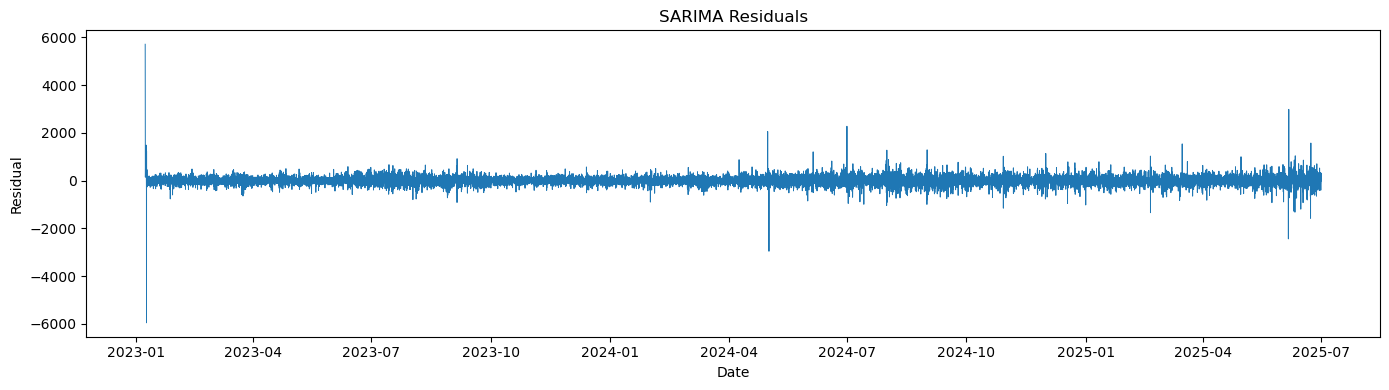

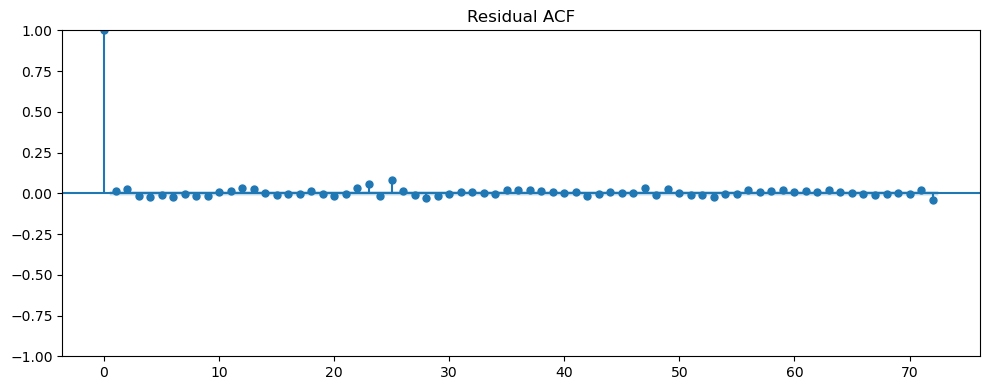

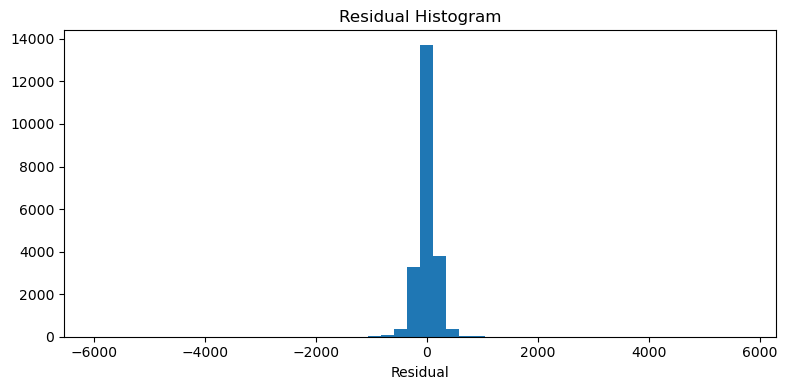

In [9]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings("ignore")

target_col = "load"
order = (2, 0, 1)
seasonal_order = (0, 1, 1, 24)

# fit once on the full series
series = df.loc[:"2025-06-30 23:00:00",target_col].dropna().asfreq("h")

model = SARIMAX(
    series,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit = model.fit(disp=False)

print("\nSARIMA summary:")
print(fit.summary())

resid = fit.resid.dropna()

print("\nLjung-Box at lag 24:")
lb_24 = acorr_ljungbox(resid, lags=[24], return_df=True)
print(lb_24)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(resid.index, resid.values, linewidth=0.7)
ax.set_title("SARIMA Residuals")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resid, lags=72, ax=ax)
ax.set_title("Residual ACF")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(resid, bins=50)
ax.set_title("Residual Histogram")
ax.set_xlabel("Residual")
plt.tight_layout()
plt.show()


In [2]:
df=pd.read_csv(r"C:\Users\Top Prix\OneDrive\New folder\Thesis_Project\data\feature_engineered_data.csv")

In [3]:
df['timestamp']=pd.to_datetime(df['timestamp'])
df=df.set_index('timestamp')


Monthly refit 1/6 — 2025-07-01
  Train rows: 21720 | Test rows: 744
  Done — 744 hours forecasted
  Monthly MAE=1073.33 | RMSE=1306.24 | MAPE=7.75%

Monthly refit 2/6 — 2025-08-01
  Train rows: 22464 | Test rows: 744
  Done — 744 hours forecasted
  Monthly MAE=875.15 | RMSE=1127.50 | MAPE=6.53%

Monthly refit 3/6 — 2025-09-01
  Train rows: 23208 | Test rows: 720
  Done — 720 hours forecasted
  Monthly MAE=2191.45 | RMSE=2761.14 | MAPE=23.25%

Monthly refit 4/6 — 2025-10-01
  Train rows: 23928 | Test rows: 744
  Done — 744 hours forecasted
  Monthly MAE=692.14 | RMSE=874.51 | MAPE=9.02%

Monthly refit 5/6 — 2025-11-01
  Train rows: 24672 | Test rows: 720
  Done — 720 hours forecasted
  Monthly MAE=418.47 | RMSE=571.37 | MAPE=5.06%

Monthly refit 6/6 — 2025-12-01
  Train rows: 25392 | Test rows: 744
  Done — 744 hours forecasted
  Monthly MAE=336.54 | RMSE=437.25 | MAPE=3.82%

SARIMA Walk-Forward Results
MAE  = 927.12 MW
RMSE = 1399.63 MW
MAPE = 9.18 %

Monthly metrics by origin:
  orig

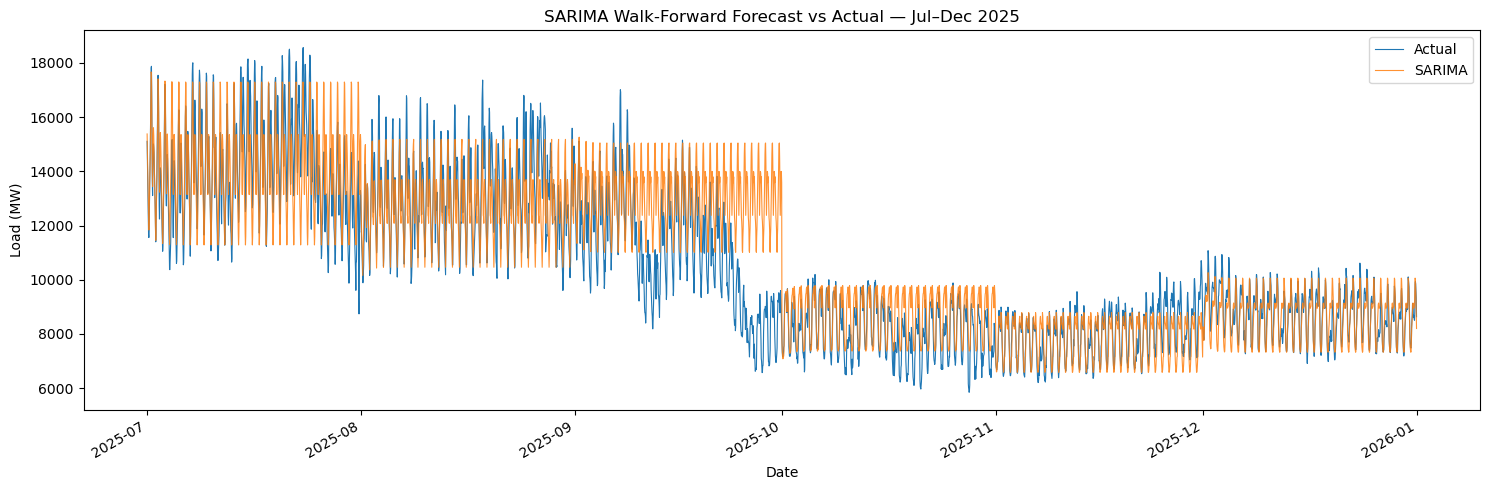

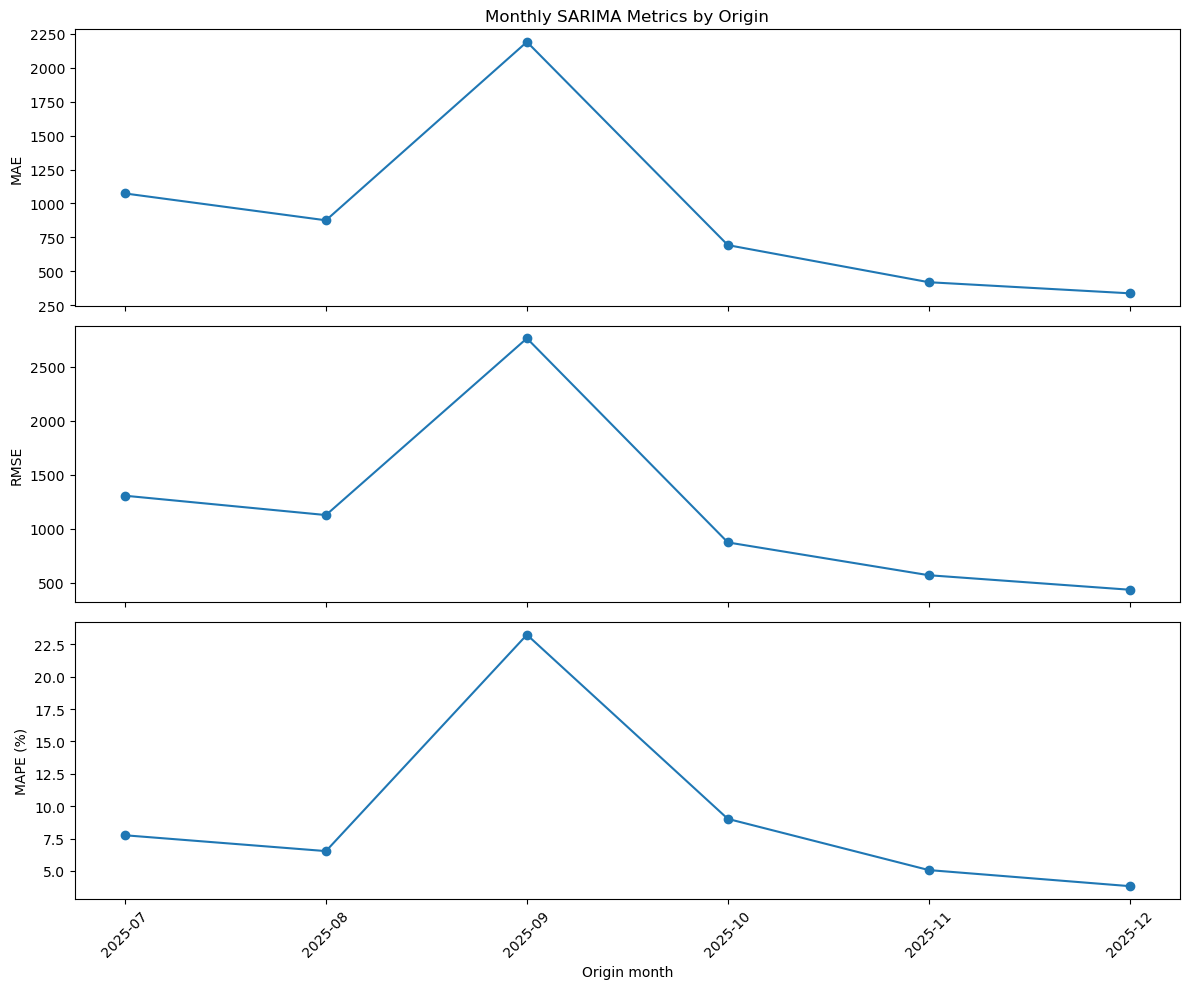


Last-origin SARIMA summary:
                                     SARIMAX Results                                      
Dep. Variable:                               load   No. Observations:                25392
Model:             SARIMAX(2, 0, 1)x(0, 1, 1, 24)   Log Likelihood             -169558.851
Date:                            Mon, 27 Apr 2026   AIC                         339127.702
Time:                                    22:47:21   BIC                         339168.403
Sample:                                01-08-2023   HQIC                        339140.867
                                     - 11-30-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1902      0.016     74.043      0.000       1.159       1.222
ar.L2 

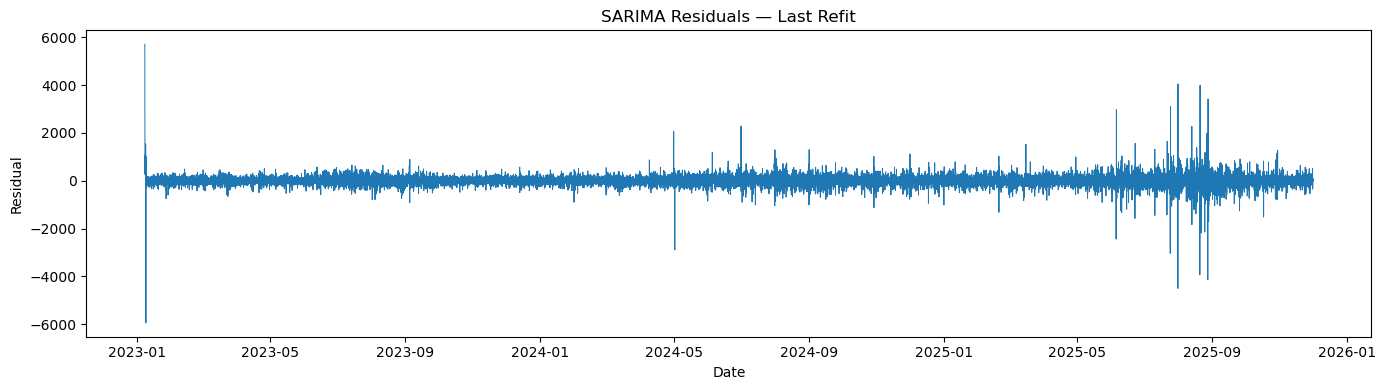

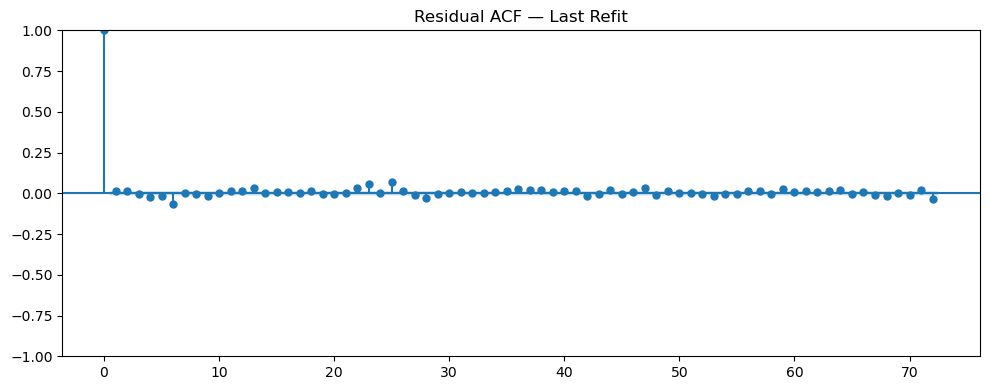

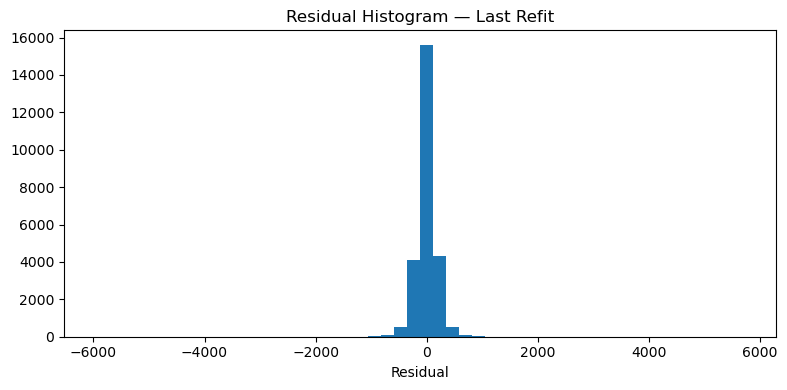

🏃 View run SARIMA_walkforward_monthly_final at: http://127.0.0.1:5000/#/experiments/531580567308328190/runs/21159c4fbd5149cbb02b4ace4fea4c98
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/531580567308328190


In [4]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings("ignore")

# ============================================================
# 1) SETTINGS
# ============================================================
target_col = "load"
month_origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

# final retained model
order = (2, 0, 1)
seasonal_order = (0, 1, 1, 24)

preds_sarima = []
actuals_sarima = []
monthly_metrics = []
sarima_summaries = {}
residual_diagnostics = {}

# ============================================================
# 2) MONTHLY WALK-FORWARD
# ============================================================
for i, origin in enumerate(month_origins):
    print(f"\n{'='*60}")
    print(f"Monthly refit {i+1}/6 — {origin.date()}")

    next_month_origin = (
        month_origins[i + 1]
        if i < len(month_origins) - 1
        else pd.Timestamp("2026-01-01 00:00:00")
    )

    train_series = (
        df.loc[: origin - pd.Timedelta(hours=1), target_col]
        .dropna()
        .asfreq("h")
    )

    test_series = (
        df.loc[
            (df.index >= origin) & (df.index < next_month_origin),
            target_col
        ]
        .dropna()
        .asfreq("h")
    )

    if len(test_series) == 0:
        print("  Skipped — empty test block")
        continue

    print(f"  Train rows: {len(train_series)} | Test rows: {len(test_series)}")

    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)
    sarima_summaries[str(origin.date())] = fit.summary()

    forecast = fit.forecast(steps=len(test_series))
    forecast = pd.Series(forecast.values, index=test_series.index)

    preds_sarima.append(forecast)
    actuals_sarima.append(test_series)

    # -------------------------
    # monthly metrics
    # -------------------------
    mae_m  = np.mean(np.abs(test_series - forecast))
    rmse_m = np.sqrt(np.mean((test_series - forecast) ** 2))
    mape_m = np.mean(np.abs((test_series - forecast) / test_series)) * 100

    monthly_metrics.append({
        "origin_month": origin.strftime("%Y-%m"),
        "n_hours": len(test_series),
        "MAE": mae_m,
        "RMSE": rmse_m,
        "MAPE": mape_m
    })

    # -------------------------
    # residual diagnostics on training fit
    # -------------------------
    resid = fit.resid.dropna()

    lb_24 = acorr_ljungbox(resid, lags=[24], return_df=True)
    residual_diagnostics[str(origin.date())] = {
        "ljungbox_lag24_stat": float(lb_24["lb_stat"].iloc[0]),
        "ljungbox_lag24_pvalue": float(lb_24["lb_pvalue"].iloc[0]),
        "residual_mean": float(resid.mean()),
        "residual_std": float(resid.std())
    }

    print(f"  Done — {len(test_series)} hours forecasted")
    print(f"  Monthly MAE={mae_m:.2f} | RMSE={rmse_m:.2f} | MAPE={mape_m:.2f}%")

# ============================================================
# 3) OVERALL METRICS
# ============================================================
pred_sarima = pd.concat(preds_sarima).sort_index()
actual_sarima = pd.concat(actuals_sarima).sort_index()

mae  = np.mean(np.abs(actual_sarima - pred_sarima))
rmse = np.sqrt(np.mean((actual_sarima - pred_sarima) ** 2))
mape = np.mean(np.abs((actual_sarima - pred_sarima) / actual_sarima)) * 100

print(f"\nSARIMA Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ============================================================
# 4) MONTHLY METRICS TABLE
# ============================================================
monthly_metrics_df = pd.DataFrame(monthly_metrics)
print("\nMonthly metrics by origin:")
print(monthly_metrics_df)

# ============================================================
# 5) SAVE TABLES
# ============================================================
monthly_metrics_df.to_csv("sarima_monthly_metrics.csv", index=False)

pred_vs_actual_df = pd.DataFrame({
    "actual": actual_sarima,
    "predicted": pred_sarima
})
pred_vs_actual_df.to_csv("sarima_walkforward_predictions.csv")

# ============================================================
# 6) PLOT: OVERALL FORECAST VS ACTUAL
# ============================================================
fig_main, ax = plt.subplots(figsize=(15, 5))
ax.plot(actual_sarima.index, actual_sarima.values, label="Actual", linewidth=0.8)
ax.plot(pred_sarima.index, pred_sarima.values, label="SARIMA", linewidth=0.8, alpha=0.85)
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("SARIMA Walk-Forward Forecast vs Actual — Jul–Dec 2025")
ax.legend()
fig_main.autofmt_xdate()
plt.tight_layout()
plt.show()

# ============================================================
# 7) PLOT: MONTHLY METRICS
# ============================================================
fig_metrics, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(monthly_metrics_df["origin_month"], monthly_metrics_df["MAE"], marker="o")
axes[0].set_ylabel("MAE")
axes[0].set_title("Monthly SARIMA Metrics by Origin")

axes[1].plot(monthly_metrics_df["origin_month"], monthly_metrics_df["RMSE"], marker="o")
axes[1].set_ylabel("RMSE")

axes[2].plot(monthly_metrics_df["origin_month"], monthly_metrics_df["MAPE"], marker="o")
axes[2].set_ylabel("MAPE (%)")
axes[2].set_xlabel("Origin month")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 8) DIAGNOSTICS ON LAST REFIT
# ============================================================
last_origin = month_origins[-1]
last_train = (
    df.loc[: last_origin - pd.Timedelta(hours=1), target_col]
    .dropna()
    .asfreq("h")
)

last_fit = SARIMAX(
    last_train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print("\nLast-origin SARIMA summary:")
print(last_fit.summary())

resid = last_fit.resid.dropna()

lb_24 = acorr_ljungbox(resid, lags=[24], return_df=True)
print("\nLjung-Box at lag 24:")
print(lb_24)

fig_resid, ax = plt.subplots(figsize=(14, 4))
ax.plot(resid.index, resid.values, linewidth=0.7)
ax.set_title("SARIMA Residuals — Last Refit")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")
plt.tight_layout()
plt.show()

fig_acf, ax = plt.subplots(figsize=(10, 4))
plot_acf(resid, lags=72, ax=ax)
ax.set_title("Residual ACF — Last Refit")
plt.tight_layout()
plt.show()

fig_hist, ax = plt.subplots(figsize=(8, 4))
ax.hist(resid, bins=50)
ax.set_title("Residual Histogram — Last Refit")
ax.set_xlabel("Residual")
plt.tight_layout()
plt.show()

# ============================================================
# 9) MLFLOW LOGGING
# ============================================================
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Electricity_Demand_Forecasting")

with mlflow.start_run(run_name="SARIMA_walkforward_monthly_final"):
    mlflow.log_param("model", "SARIMA")
    mlflow.log_param("order", str(order))
    mlflow.log_param("seasonal_order", str(seasonal_order))
    mlflow.log_param("refit_frequency", "monthly")
    mlflow.log_param("forecast_horizon", "monthly_block")

    mlflow.log_metric("MAE", float(mae))
    mlflow.log_metric("RMSE", float(rmse))
    mlflow.log_metric("MAPE", float(mape))

    mlflow.log_artifact("sarima_monthly_metrics.csv")
    mlflow.log_artifact("sarima_walkforward_predictions.csv")

    fig_main.savefig("sarima_walkforward_forecast.png")
    mlflow.log_artifact("sarima_walkforward_forecast.png")

In [4]:
import os
import joblib
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ============================================================
# 1) SETTINGS
# ============================================================
os.makedirs("models", exist_ok=True)

target_col = "load"

order = (2, 0, 1)
seasonal_order = (0, 1, 1, 24)

# ============================================================
# 2) PREPARE FULL SERIES
# ============================================================
series = (
    df[target_col]
    .dropna()
    .asfreq("h")
)

print(f"Training SARIMA on {len(series)} observations")

# ============================================================
# 3) FIT FINAL SARIMA ON FULL AVAILABLE DATA
# ============================================================
sarima_model = SARIMAX(
    series,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

# ============================================================
# 4) SAVE MODEL + CONFIG
# ============================================================
sarima_fit.save("models/sarima_final.pkl")

sarima_config = {
    "model": "SARIMA",
    "order": order,
    "seasonal_order": seasonal_order,
    "target_col": target_col,
    "frequency": "h"
}

joblib.dump(sarima_config, "models/sarima_config.pkl")

print("Saved SARIMA model to models/sarima_final.pkl")
print("Saved SARIMA config to models/sarima_config.pkl")

Training SARIMA on 26136 observations


c:\conda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                               load   No. Observations:                26136
Model:             SARIMAX(2, 0, 1)x(0, 1, 1, 24)   Log Likelihood             -174427.502
Date:                            Sun, 03 May 2026   AIC                         348865.003
Time:                                    19:37:26   BIC                         348905.849
Sample:                                01-08-2023   HQIC                        348878.197
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1816      0.016     73.228      0.000       1.150       1.213
ar.L2         -0.2195      0.016   

In [ ]:
jan_apr_2023 = df['load']['2023-01':'2023-04'].resample('M').mean()
jan_apr_2024 = df['load']['2024-01':'2024-04'].resample('M').mean()
jan_apr_2025 = df['load']['2025-01':'2025-04'].resample('M').mean()

import pandas as pd
comparison = pd.DataFrame({
    '2023': jan_apr_2023.values,
    '2024': jan_apr_2024.values,
    '2025': jan_apr_2025.values
}, index=['Jan', 'Feb', 'Mar', 'Apr'])

print(comparison)
print(f"\nYoY growth 2023→2024: {((jan_apr_2024.mean() - jan_apr_2023.mean()) / jan_apr_2023.mean() * 100):.1f}%")
print(f"YoY growth 2024→2025: {((jan_apr_2025.mean() - jan_apr_2024.mean()) / jan_apr_2024.mean() * 100):.1f}%")

            2023         2024         2025
Jan  6962.154948  5930.971539  8778.512553
Feb  6037.589178  5774.363147  8686.830608
Mar  5792.321142  5621.902554  7714.998549
Apr  5258.734792  5109.445660  7758.670623

YoY growth 2023→2024: -6.7%
YoY growth 2024→2025: 46.8%


C:\Users\Top Prix\AppData\Local\Temp\ipykernel_1336\3705854651.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  jan_apr_2023 = df['load']['2023-01':'2023-04'].resample('M').mean()
C:\Users\Top Prix\AppData\Local\Temp\ipykernel_1336\3705854651.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  jan_apr_2024 = df['load']['2024-01':'2024-04'].resample('M').mean()
C:\Users\Top Prix\AppData\Local\Temp\ipykernel_1336\3705854651.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  jan_apr_2025 = df['load']['2025-01':'2025-04'].resample('M').mean()



Origin 1/6 — 2025-07-01


c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


  Done — 744 hours forecasted

Origin 2/6 — 2025-08-01


c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


  Done — 744 hours forecasted

Origin 3/6 — 2025-09-01


...

  Done — 744 hours forecasted

Origin 5/6 — 2025-11-01


c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


  Done — 720 hours forecasted

Origin 6/6 — 2025-12-01


c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


  Done — 744 hours forecasted

SARIMA Walk-Forward Results
MAE  = 927.37 MW
RMSE = 1400.61 MW
MAPE = 9.18 %


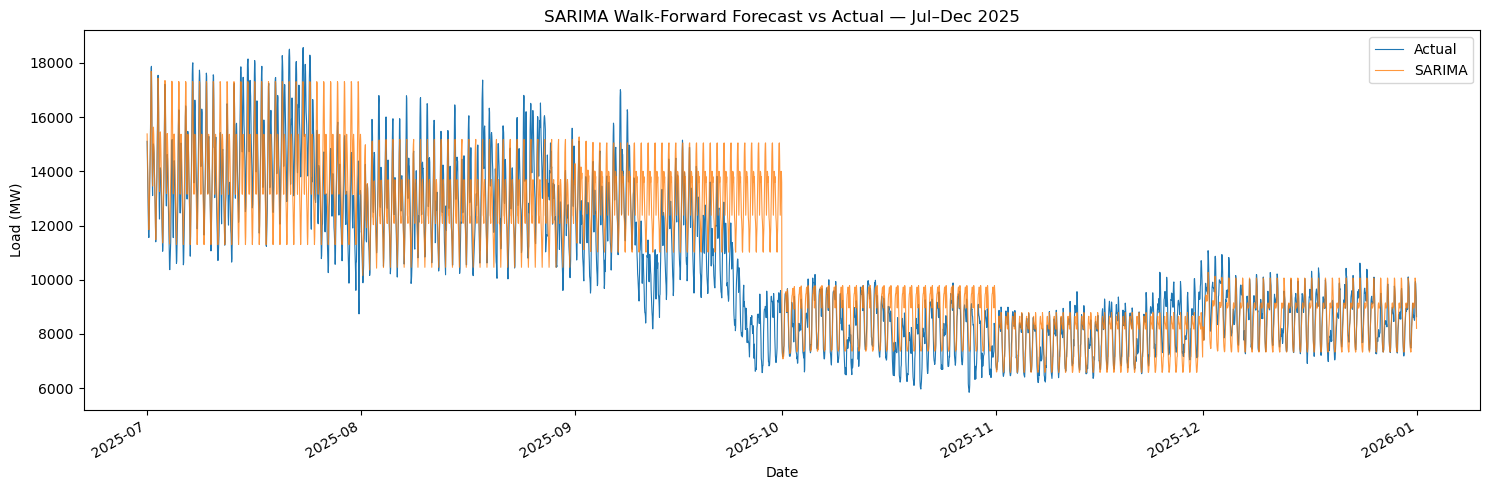

🏃 View run SARIMA_walkforward at: http://127.0.0.1:5000/#/experiments/4/runs/70278142cdcd4e1e82846377d1f8d784
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


In [4]:

# ── target series (must have DatetimeIndex) ───────────────────
y = df['load']

# ── walk-forward loop ─────────────────────────────────────────
origins = pd.date_range("2025-07-01", "2025-12-01", freq="MS")

preds_sarima   = []
actuals_sarima = []

for i, origin in enumerate(origins):
    print(f"\n{'='*50}")
    print(f"Origin {i+1}/6 — {origin.date()}")

    month_end   = origin + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23)
    train       = y.loc[: origin - pd.Timedelta(hours=1)]
    actual_month = y.loc[origin : month_end]

    model = SARIMAX(
        train,
        order=(2, 0, 0),
        seasonal_order=(0, 1, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    pred_month = model.forecast(steps=len(actual_month))
    pred_month.index = actual_month.index

    preds_sarima.append(pred_month)
    actuals_sarima.append(actual_month)
    print(f"  Done — {len(actual_month)} hours forecasted")

# ── metrics ───────────────────────────────────────────────────
pred_sarima   = pd.concat(preds_sarima).sort_index()
actual_sarima = pd.concat(actuals_sarima).sort_index()

mae  = np.mean(np.abs(actual_sarima - pred_sarima))
rmse = np.sqrt(np.mean((actual_sarima - pred_sarima)**2))
mape = np.mean(np.abs((actual_sarima - pred_sarima) / actual_sarima)) * 100

print(f"\nSARIMA Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ── plot ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(actual_sarima.index, actual_sarima.values, label='Actual', linewidth=0.8)
ax.plot(pred_sarima.index, pred_sarima.values, label='SARIMA', linewidth=0.8, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Load (MW)')
ax.set_title('SARIMA Walk-Forward Forecast vs Actual — Jul–Dec 2025')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# ── mlflow logging ────────────────────────────────────────────
with mlflow.start_run(run_name="SARIMA_walkforward"):
    mlflow.log_param("model", "SARIMA")
    mlflow.log_param("order", "(2,0,1)")
    mlflow.log_param("seasonal_order", "(0,1,0,24)")
    mlflow.log_param("refit_frequency", "monthly")
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAPE", mape)
    fig.savefig("sarima_forecast.png")
    mlflow.log_artifact("sarima_forecast.png")

c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\conda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                      
Dep. Variable:                                load   No. Observations:                21720
Model:             SARIMAX(2, 0, 1)x(0, 1, [], 24)   Log Likelihood             -145950.524
Date:                             Tue, 07 Apr 2026   AIC                         291909.049
Time:                                     16:04:31   BIC                         291940.988
Sample:                                 01-08-2023   HQIC                        291919.457
                                      - 06-30-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4692      0.032     45.735      0.000       1.406       1.532
ar.L2         -0.5119      

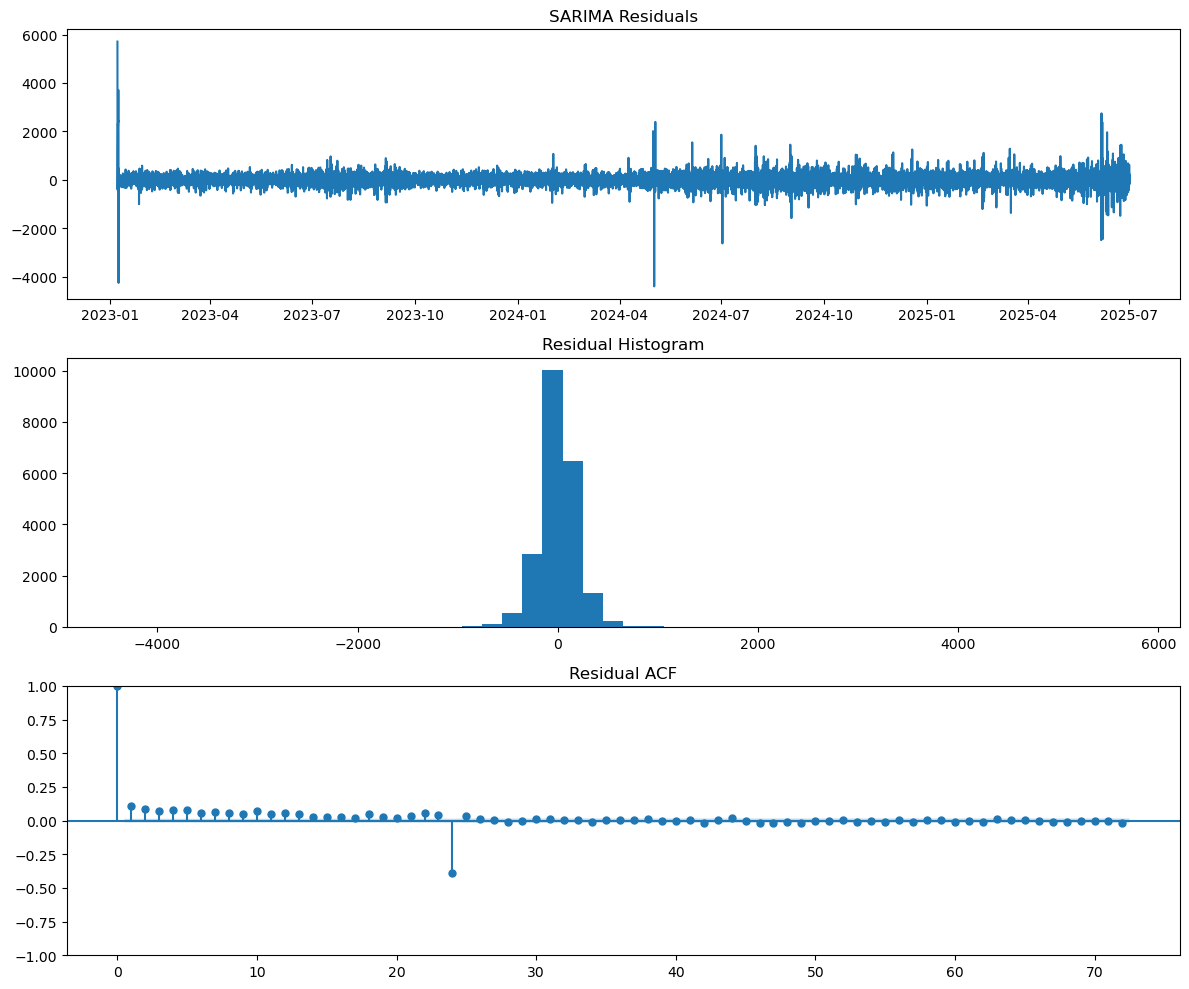

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# full training set used before the test period
train = y.loc[: "2025-06-30 23:00:00"]

# fit retained SARIMA specification on the training set
sarima_diag = SARIMAX(
    train,
    order=(2, 0, 0),
    seasonal_order=(0, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

resid = sarima_diag.resid

print(sarima_diag.summary())

# Ljung-Box test
lb = acorr_ljungbox(resid, lags=[24, 48], return_df=True)
print("\nLjung-Box test:")
print(lb)

# residual plots
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(resid)
axes[0].set_title("SARIMA Residuals")

axes[1].hist(resid, bins=50)
axes[1].set_title("Residual Histogram")

plot_acf(resid, lags=72, ax=axes[2])
axes[2].set_title("Residual ACF")

plt.tight_layout()
plt.show()

In [ ]:
# ── target series (must have DatetimeIndex) ───────────────────
y = df['load']

# ── walk-forward loop ─────────────────────────────────────────
origins = pd.date_range("2025-07-01", "2025-12-01", freq="7D")

preds_sarima   = []
actuals_sarima = []

for i, origin in enumerate(origins):
    print(f"\n{'='*50}")
    print(f"Origin {i+1}/27 — {origin.date()}")

    month_end   = origin + pd.offsets.MonthEnd(0) + pd.Timedelta(hours=23)
    train       = y.loc[: origin - pd.Timedelta(hours=1)]
    actual_month = y.loc[origin : month_end]

    model = SARIMAX(
        train,
        order=(2, 0, 0),
        seasonal_order=(0, 1, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    pred_month = model.forecast(steps=len(actual_month))
    pred_month.index = actual_month.index

    preds_sarima.append(pred_month)
    actuals_sarima.append(actual_month)
    print(f"  Done — {len(actual_month)} hours forecasted")

# ── metrics ───────────────────────────────────────────────────
pred_sarima   = pd.concat(preds_sarima).sort_index()
actual_sarima = pd.concat(actuals_sarima).sort_index()

mae  = np.mean(np.abs(actual_sarima - pred_sarima))
rmse = np.sqrt(np.mean((actual_sarima - pred_sarima)**2))
mape = np.mean(np.abs((actual_sarima - pred_sarima) / actual_sarima)) * 100

print(f"\nSARIMA Walk-Forward Results")
print(f"MAE  = {mae:.2f} MW")
print(f"RMSE = {rmse:.2f} MW")
print(f"MAPE = {mape:.2f} %")

# ── plot ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(actual_sarima.index, actual_sarima.values, label='Actual', linewidth=0.8)
ax.plot(pred_sarima.index, pred_sarima.values, label='SARIMA', linewidth=0.8, alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Load (MW)')
ax.set_title('SARIMA Walk-Forward Forecast vs Actual — Jul–Dec 2025')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()